In [1]:
!pip install -q trl bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.9/532.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 34.1 MB/s eta 0:00:00


In [2]:
import os
import torch
from pathlib import Path
import json
from datasets import load_dataset
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, TrainerCallback, BitsAndBytesConfig
from huggingface_hub import login, HfApi, create_repo, upload_folder
from kaggle_secrets import UserSecretsClient
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer
import math
import matplotlib.pyplot as plt

2026-01-25 09:50:18.744254: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769334618.973146      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769334619.041540      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769334619.574867      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769334619.574905      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769334619.574908      24 computation_placer.cc:177] computation placer alr

In [ ]:
MODEL_NAME="Qwen/Qwen2.5-7B-Instruct"

# change depending on the language
LANGUAGE = "Spanish"

DATA_PATH = f'/kaggle/input/chatbot-dataset/{LANGUAGE}_training_data.jsonl'

user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HF_TOKEN_W")
login(HF_TOKEN)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, start=1):
        try:
            data = json.loads(line)
            if not isinstance(data, dict):
                print(f"Line {i} is not a dict! Type={type(data)}")
            elif "messages" not in data:
                print(f"Line {i} missing 'messages'")
            elif not isinstance(data["messages"], list):
                print(f"Line {i} 'messages' is not a list, type={type(data['messages'])}")
            elif "metadata" not in data:
                print(f"Line {i} missing 'metadata'")
        except json.JSONDecodeError as e:
            print(f"Line {i} failed to parse: {e}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [4]:
dataset = load_dataset(
    "json",
    data_files=DATA_PATH,
    split="train"
)

Generating train split: 0 examples [00:00, ? examples/s]

In [5]:
# to format the text into template for Llama
def format_chat(example):
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False
    )
    return {"text": text}

# to check length of token
def compute_len(example):
    return {"len": len(tokenizer(example["text"])["input_ids"])}

In [6]:
# apply template
dataset = dataset.map(
    format_chat,
    remove_columns=dataset.column_names
)

lengths = dataset.map(
    compute_len
)

dataset= dataset.train_test_split(
    test_size=0.05,
    seed=42
)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [7]:
all_lens = lengths["len"]

mean_len = sum(all_lens) / len(all_lens)
max_len = max(all_lens)
min_len = min(all_lens)

print(f"Mean token length: {mean_len:.2f}")
print(f"Max token length: {max_len}")
print(f"Min token length: {min_len}")

Mean token length: 318.96
Max token length: 1036
Min token length: 127


In [8]:
# lora norms used to calculate how far finetuned model moved from base model
def compute_lora_norms(model):
    norms = {}
    total_norm = 0.0

    for name, param in model.named_parameters():
        if "lora_" in name and param.requires_grad:
            norm = torch.norm(param.detach()).item()
            norms[name] = norm
            total_norm += norm ** 2

    total_norm = total_norm ** 0.5
    return total_norm, norms

In [9]:
class MetricsCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.eval_losses = []
        self.perplexities = []
        self.lora_norms = []
        self.steps = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return

        if "loss" in logs:
            self.train_losses.append(logs["loss"])
            self.steps.append(state.global_step)

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is None:
            return

        eval_loss = metrics.get("eval_loss")
        if eval_loss is not None:
            self.eval_losses.append(eval_loss)
            self.perplexities.append(math.exp(eval_loss))

        model = kwargs["model"]
        lora_norm, _ = compute_lora_norms(model)
        self.lora_norms.append(lora_norm)

In [10]:
print("Downloading model")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)

base.enable_input_require_grads()
base.gradient_checkpointing_enable()
base.config.use_cache = False

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/3.95G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.56G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

In [11]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
)

model = get_peft_model(base, lora_config)
model.print_trainable_parameters()

metrics_callback = MetricsCallback()

trainable params: 40,370,176 || all params: 7,655,986,688 || trainable%: 0.5273


In [12]:
print("training started")

training_args = TrainingArguments(
    output_dir=f"/kaggle/working/qwen/{LANGUAGE}/checkpoints",

    # these two show how often optimizer works 
    # how many sample per GPU step
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    # how many steps for gradient accumulation
    gradient_accumulation_steps=4,

    learning_rate=1e-4,
    num_train_epochs=4,
    
    warmup_ratio=0.05,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    optim="paged_adamw_8bit",

    logging_steps=50,

    eval_strategy="steps",
    eval_steps=100,

    save_steps=100,
    save_total_limit=3,

    ddp_find_unused_parameters=False,
    
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",

    report_to="none"
)

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    args=training_args,
    callbacks=[metrics_callback],
)

trainer.train()

training started


/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:2111: FutureWarning: `--push_to_hub_token` is deprecated and will be removed in version 5 of 🤗 Transformers. Use `--hub_token` instead.
  warnings.warn(


Adding EOS to train dataset:   0%|          | 0/1900 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1900 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1900 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
100,1.155900,1.106727
200,1.065200,1.126603
300,0.980800,1.056521
400,0.933100,1.046395


TrainOutput(global_step=476, training_loss=1.0780622498327945, metrics={'train_runtime': 12776.5302, 'train_samples_per_second': 0.595, 'train_steps_per_second': 0.037, 'total_flos': 1.49999094771499e+17, 'train_loss': 1.0780622498327945})

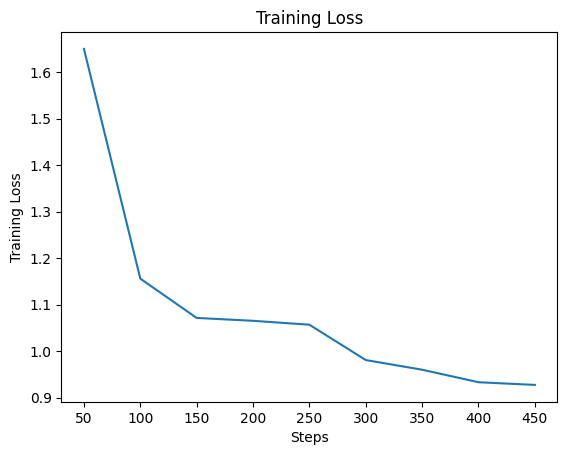

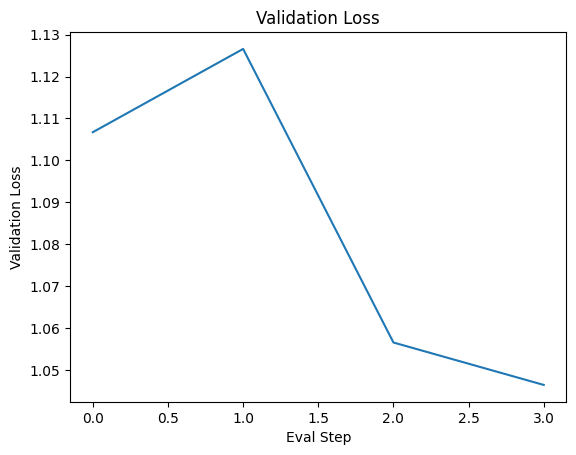

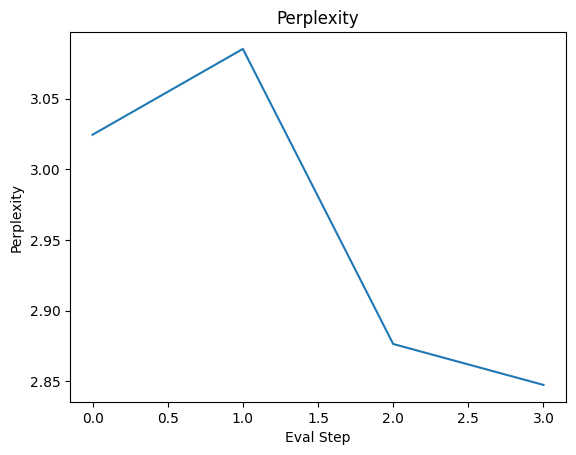

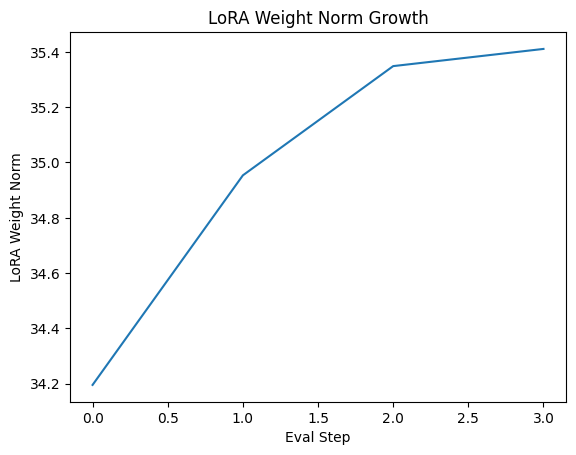

In [13]:
# Training loss
plt.figure()
plt.plot(metrics_callback.steps, metrics_callback.train_losses)
plt.xlabel("Steps")
plt.ylabel("Training Loss")
plt.title("Training Loss")
plt.show()

# Validation loss
plt.figure()
plt.plot(metrics_callback.eval_losses)
plt.xlabel("Eval Step")
plt.ylabel("Validation Loss")
plt.title("Validation Loss")
plt.show()

# training and validation loss should decrease together
# perplexity should decrease and the plateau
# lora norms should grow and plateau 

# Perplexity
plt.figure()
plt.plot(metrics_callback.perplexities)
plt.xlabel("Eval Step")
plt.ylabel("Perplexity")
plt.title("Perplexity")
plt.show()

# LoRA weight norms
plt.figure()
plt.plot(metrics_callback.lora_norms)
plt.xlabel("Eval Step")
plt.ylabel("LoRA Weight Norm")
plt.title("LoRA Weight Norm Growth")
plt.show()

In [14]:
final_dir = f"/kaggle/working/qwen/{LANGUAGE}/final"

trainer.model.save_pretrained(final_dir)
tokenizer.save_pretrained(final_dir)

('/kaggle/working/qwen/Spanish/final/tokenizer_config.json',
 '/kaggle/working/qwen/Spanish/final/special_tokens_map.json',
 '/kaggle/working/qwen/Spanish/final/chat_template.jinja',
 '/kaggle/working/qwen/Spanish/final/vocab.json',
 '/kaggle/working/qwen/Spanish/final/merges.txt',
 '/kaggle/working/qwen/Spanish/final/added_tokens.json',
 '/kaggle/working/qwen/Spanish/final/tokenizer.json')

In [15]:
api = HfApi(token=HF_TOKEN)
model_name_for_repo = MODEL_NAME.split('/')[-1]
OUTPUT_REPO = f"jiminaa/{model_name_for_repo}-language-QLoRA"

try:
    create_repo(
        repo_id=OUTPUT_REPO, 
        exist_ok=True, 
        repo_type="model", 
        token=HF_TOKEN
    )
    print(f"Repository ready: {OUTPUT_REPO}")
except Exception as e:
    print(f"Note: {e}")

try:
    upload_folder(
        folder_path=final_dir,
        repo_id=OUTPUT_REPO,
        path_in_repo=f"{LANGUAGE}",
        repo_type="model",
        token=HF_TOKEN
    )
except Exception as e:
    print(f"Note: {e}")


Repository ready: jiminaa/Qwen2.5-7B-Instruct-language-QLoRA


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            